In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyextremes import EVA
import pyextremes


In [2]:
# Loading and parsing CSV data
df = pd.read_csv("grid_120.9999999999995453_14.5999999999999144.csv")


In [3]:
df = df.sort_values(["start_time"])
df

,tc_sid,max_wind_speed,start_time,end_time,SID,Name
219,1980076N06148,11.544622,1980-03-23 09:00:00,1980-03-25 12:00:00,1980076N06148,UNNAMED
141,1980126N08150,13.249553,1980-05-13 12:00:00,1980-05-15 21:00:00,1980126N08150,DOM
189,1980137N04158,14.567233,1980-05-24 03:00:00,1980-05-26 06:00:00,1980137N04158,FORREST
421,1980171N06142,10.452479,1980-06-22 21:00:00,1980-06-24 06:00:00,1980171N06142,HERBERT
76,1980181N10130,10.170428,1980-06-29 12:00:00,1980-07-01 09:00:00,1980181N10130,UNNAMED
...,...,...,...,...,...,...
271,2024293N13141,20.815958,2024-10-23 09:00:00,2024-10-24 21:00:00,2024293N13141,TRAMI
326,2024308N08140,3.810449,2024-11-07 00:00:00,2024-11-07 21:00:00,2024308N08140,YINXING
199,2024313N15138,10.717240,2024-11-10 21:00:00,2024-11-11 15:00:00,2024313N15138,TORAJI
19,2024314N07151,7.944938,2024-11-13 21:00:00,2024-11-14 18:00:00,2024314N07151,USAGI


In [4]:
# Extracting max wind speed and cleaning data
wind_speeds = df['max_wind_speed'].dropna().astype(float)
wind_speeds = wind_speeds[wind_speeds > 0]  # Remove invalid entries
wind_speeds

219    11.544622
141    13.249553
189    14.567233
421    10.452479
76     10.170428
         ...    
271    20.815958
326     3.810449
199    10.717240
19      7.944938
15     16.708851
Name: max_wind_speed, Length: 445, dtype: float64

In [5]:
df['start_time'] = pd.to_datetime(df['start_time'])


In [6]:
data = df[['start_time','max_wind_speed']].dropna(subset='max_wind_speed').set_index('start_time')

data = data.sort_index(ascending=True)
series = data.squeeze()
series

start_time
1980-03-23 09:00:00    11.544622
1980-05-13 12:00:00    13.249553
1980-05-24 03:00:00    14.567233
1980-06-22 21:00:00    10.452479
1980-06-29 12:00:00    10.170428
                         ...    
2024-10-23 09:00:00    20.815958
2024-11-07 00:00:00     3.810449
2024-11-10 21:00:00    10.717240
2024-11-13 21:00:00     7.944938
2024-11-16 03:00:00    16.708851
Name: max_wind_speed, Length: 445, dtype: float64

22.284223403930667


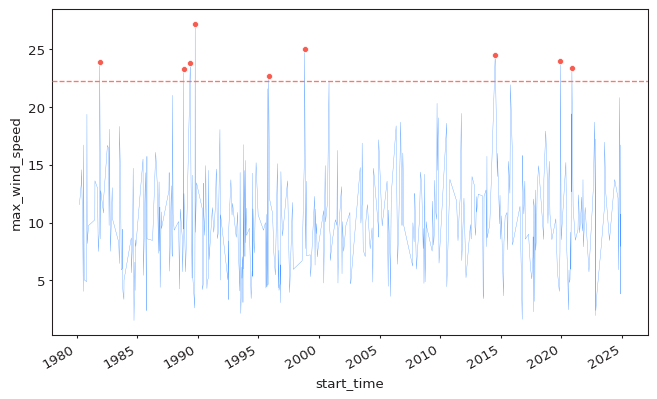

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pyextremes/eva.py:1251: RuntimeWarning: divide by zero encountered in divide
  exceedance_probability = 1 / return_period / extremes_rate
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


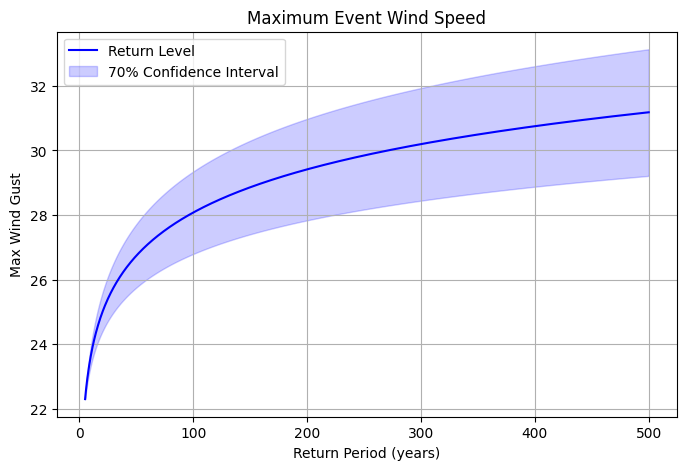

In [10]:
model = EVA(series)

threshold = np.percentile(series, 98)
print(threshold)
model.get_extremes(method='POT', threshold=threshold)
model.plot_extremes()
plt.savefig(f"POT.png", dpi=300, bbox_inches="tight")
plt.show()

# Fit the extreme value model (Generalized Pareto Distribution for POT)
model.fit_model()

# Define return periods 
return_periods = np.linspace(0, 500, 1000)

summary = model.get_summary(return_period=return_periods, alpha=0.7, n_samples=1000)

# Plot exceedance probability (return level vs return period)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(return_periods, summary['return value'], label='Return Level', color='blue')
ax.fill_between(return_periods, summary['lower ci'], summary['upper ci'], color='blue', alpha=0.2, label='70% Confidence Interval')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Max Wind Gust')
ax.set_title('Maximum Event Wind Speed')
ax.legend()
ax.grid(True)

# Save the plot
plt.savefig("RPCurve_zero_500_70ci.png", dpi=300, )

# Show the plot
plt.show()
